# Speech Emotion Recognition on CREMA-D (Classical vs Quantum)

Main Colab-ready notebook for training/evaluating classical and hybrid quantum models on CREMA-D. Supports spectrogram CNNs, MFCC CNNs, and precomputed embeddings with optional two-stage fine-tuning.


In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 49.2 MB/s eta 0:00:00


In [2]:
# Colab setup: mount Drive, clone repo, checkout fine-tunning branch
import os, sys, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/lburdman/qnn-transfer-learning.git'
REPO_PATH = Path('/content/qnn-transfer-learning')
BRANCH = 'fine-tunning'

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not REPO_PATH.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_PATH)], check=True)
    os.chdir(REPO_PATH)
    subprocess.run(['git', 'fetch'], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
else:
    os.chdir(Path('.'))

sys.path.append(str(Path.cwd() / 'src'))
print('Working dir:', Path.cwd())
print('Python path updated with src/')


Mounted at /content/drive
Working dir: /content/qnn-transfer-learning
Python path updated with src/


In [3]:
import json, time, random
from pathlib import Path
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.utils import configure_run
from src.dataset import create_dataloaders_all
from src.model_builder import build_model
from src.training import (
    train_with_history,
    train_model,
    evaluate_model,
    pretrain_backbone_and_embedding,
    finetune_head_only,
    summarize_experiments,
    freeze_module_params,
)
from src.quantum_circuit import draw_qnode_circuit_example, analyze_trained_quantum_head

print('Imports ready')


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


Imports ready


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [5]:
# Experiment configuration
DATA_ROOT = '/content/drive/MyDrive/CREMAD' if 'google.colab' in sys.modules else str(Path.cwd() / 'CREMAD')
BASE_MODEL = 'emb_resnet18'  # options: emb_resnet18, emb_vgg16, emb_panns_cnn14, cnn_specs, cnn_mfcc
USE_QUANTUM = False
FINE_TUNING = True  # True: new two-stage pipeline; False: legacy hybrid pipeline
SELECTED_CLASSES = None  # e.g., ['ANG', 'SAD'] or None for all
N_QUBITS = 10
Q_DEPTH = 2
BATCH_SIZE = 8
EPOCHS_PRETRAIN = 4
EPOCHS_FINETUNE = 8
EPOCHS = EPOCHS_FINETUNE
if FINE_TUNING:
    LR_PRETRAIN = 1e-3
    LR_FINETUNE = 2e-3
else:
    LEARNING_RATE = 2e-3
RNG_SEED = 42

random.seed(RNG_SEED); np.random.seed(RNG_SEED); torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

if FINE_TUNING:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS_FINETUNE,
        learning_rate=LR_FINETUNE,
        data_root=DATA_ROOT,
    )
    config['num_epochs_pretrain'] = EPOCHS_PRETRAIN
    config['learning_rate_pretrain'] = LR_PRETRAIN
else:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        data_root=DATA_ROOT,
    )
print(json.dumps(config, indent=2))


{
  "run_id": "11-30_22-29-41",
  "base_model": "emb_resnet18",
  "quantum": true,
  "classical_model": "512_nq_2",
  "n_qubits": 2,
  "q_depth": 3,
  "selected_classes": [
    "ANG",
    "SAD"
  ],
  "batch_size": 8,
  "num_epochs": 15,
  "learning_rate": 0.002,
  "data_root": "/content/drive/MyDrive/CREMAD",
  "specs_dir": "/content/drive/MyDrive/CREMAD/Spectrograms",
  "embedding_dir": "/content/drive/MyDrive/CREMAD/Embeddings",
  "mfcc_dir": "/content/drive/MyDrive/CREMAD/MFCCs",
  "use_pretrained": false,
  "freeze_backbone": true,
  "use_generic_weights": false,
  "grayscale": false,
  "rng_seed": 42,
  "save_root": "/content/drive/MyDrive/CREMAD/Models",
  "model_dir": "/content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41",
  "num_epochs_pretrain": 4,
  "learning_rate_pretrain": 0.001
}


In [11]:
dataloaders, dataset_sizes, class_names, counts_per_class = create_dataloaders_all(config, shuffle=True, num_workers=0)
print('Splits sizes:', dataset_sizes)
print('Classes:', class_names)
phase = 'train' if 'train' in dataloaders else list(dataloaders.keys())[0]
sample_x, sample_y = next(iter(dataloaders[phase]))
print('Sample batch shape:', sample_x.shape)
print('Label shape:', sample_y.shape)
print('Counts per class (train):', counts_per_class.get('train', {}))


Splits sizes: {'train': 1779, 'val': 481, 'test': 508}
Classes: ['ANG', 'SAD']
Sample batch shape: torch.Size([8, 512])
Label shape: torch.Size([8])
Counts per class (train): {'ANG': 890, 'SAD': 889}


ASCII circuit diagram (templates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


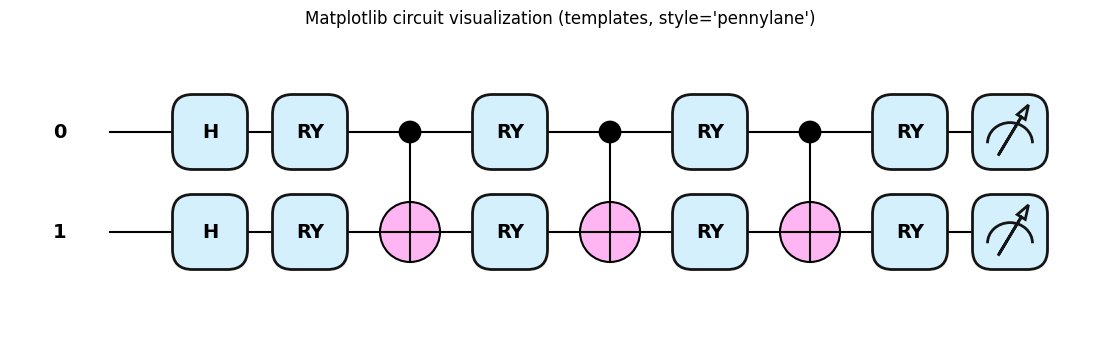


ASCII decomposed circuit (basic gates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


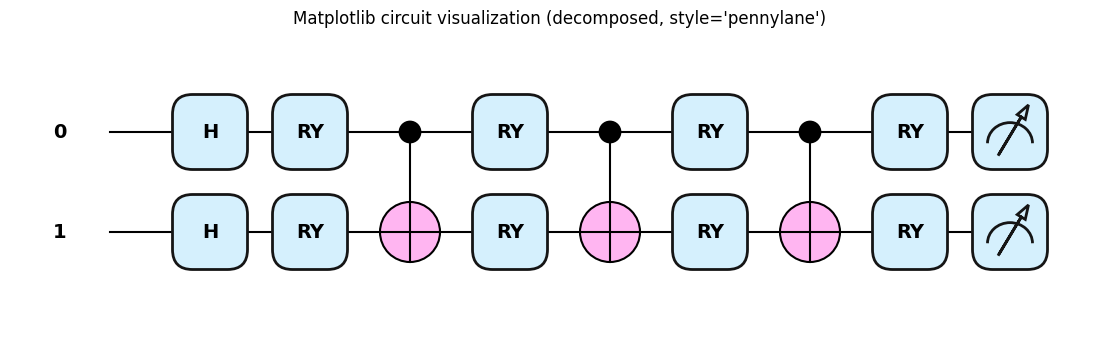

In [9]:
if USE_QUANTUM:
    try:
        draw_qnode_circuit_example(n_qubits=N_QUBITS, q_depth=Q_DEPTH, max_layers=None, seed=0)
    except Exception as exc:
        print('Quantum preview skipped:', exc)
else:
    print('Quantum preview skipped (USE_QUANTUM=False)')


In [12]:
history_stage1 = {}
history_stage2 = {}
final_acc = None
best_model = None
if FINE_TUNING:
    if BASE_MODEL in ['cnn_specs', 'cnn_mfcc']:
        ft_cfg = config.copy()
        ft_cfg.update({
            'pretrain_epochs': EPOCHS_PRETRAIN,
            'finetune_epochs': EPOCHS_FINETUNE,
            'learning_rate_pretrain': config.get('learning_rate_pretrain', 1e-3),
            'learning_rate_finetune_classical': config.get('learning_rate', 1e-3),
            'learning_rate_finetune_quantum': config.get('learning_rate', 1e-3),
            'n_qubits': N_QUBITS,
            'q_depth': Q_DEPTH,
            'backbone_dir': str(Path(DATA_ROOT) / 'Models' / 'backbone'),
        })
        _, history_stage1, checkpoint = pretrain_backbone_and_embedding(
            dataloaders, dataset_sizes, class_names, ft_cfg, representation_tag=BASE_MODEL.split('_')[-1]
        )
        head_type = 'quantum' if USE_QUANTUM else 'classical'
        best_model, history_stage2, final_acc = finetune_head_only(
            checkpoint, dataloaders, dataset_sizes, class_names, ft_cfg, head_type=head_type,
            representation_tag=BASE_MODEL.split('_')[-1]
        )
    else:
        input_dim = sample_x.shape[1] if sample_x.ndim == 2 else sample_x.shape[1]
        feature_mapper = nn.Sequential(
            nn.Linear(input_dim, max(64, N_QUBITS * 2)),
            nn.ReLU(),
            nn.Linear(max(64, N_QUBITS * 2), N_QUBITS),
            nn.ReLU(),
        ).to(device)
        head_stage1 = nn.Linear(N_QUBITS, len(class_names)).to(device)
        stage1_model = nn.Sequential(feature_mapper, head_stage1)
        model_dir_stage1 = Path(config['model_dir']) / 'stage1'
        model_dir_stage1.mkdir(parents=True, exist_ok=True)
        stage1_model, history_stage1 = train_with_history(
            stage1_model, dataloaders, dataset_sizes, device=device, num_epochs=EPOCHS_PRETRAIN, learning_rate=config.get('learning_rate_pretrain', 1e-3), model_dir=str(model_dir_stage1), phases=tuple(p for p in ('train','test') if p in dataloaders)
        )
        freeze_module_params(feature_mapper)
        if USE_QUANTUM:
            from src.model_builder import build_quantum_head
            head_stage2 = build_quantum_head(N_QUBITS, len(class_names), Q_DEPTH)
        else:
            head_stage2 = nn.Sequential(nn.Linear(N_QUBITS, 64), nn.ReLU(), nn.Linear(64, len(class_names)))
        stage2_model = nn.Sequential(feature_mapper, head_stage2).to(device)
        model_dir_stage2 = Path(config['model_dir']) / 'stage2'
        model_dir_stage2.mkdir(parents=True, exist_ok=True)
        best_model, history_stage2 = train_with_history(
            stage2_model, dataloaders, dataset_sizes, device=device, num_epochs=EPOCHS_FINETUNE, learning_rate=config.get('learning_rate', 1e-3), model_dir=str(model_dir_stage2), phases=tuple(p for p in ('train','test') if p in dataloaders)
        )
        final_acc = history_stage2.get('test_acc', [0])[-1] if history_stage2.get('test_acc') else 0
else:
    best_model = build_model(config, class_names, dataloaders, device=device)
    best_model, history_stage1 = train_model(
        best_model, dataloaders, dataset_sizes, device, config['num_epochs'], config['learning_rate'], config['model_dir']
    )
    final_acc = history_stage1.get('test_acc', [0])[-1] if history_stage1.get('test_acc') else 0
print('Final test acc estimate:', f'{final_acc:.4f}')


Epoch 1/15
------------------------------


train 1/15:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.4721  Acc: 0.8600


test 1/15:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.4585  Acc: 0.8071

Epoch 2/15
------------------------------


...

test Loss: 0.1448  Acc: 0.9469

Epoch 15/15
------------------------------


train 15/15:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.1161  Acc: 0.9685


test 15/15:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.1463  Acc: 0.9429

Training complete. Best test accuracy: 0.9469
Model saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/model.pt
Final val/test acc estimate: 0.9429133858267716


In [ ]:
# Model summary
print_model_summary(best_model)


Saved plot to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/stage1_metrics.png


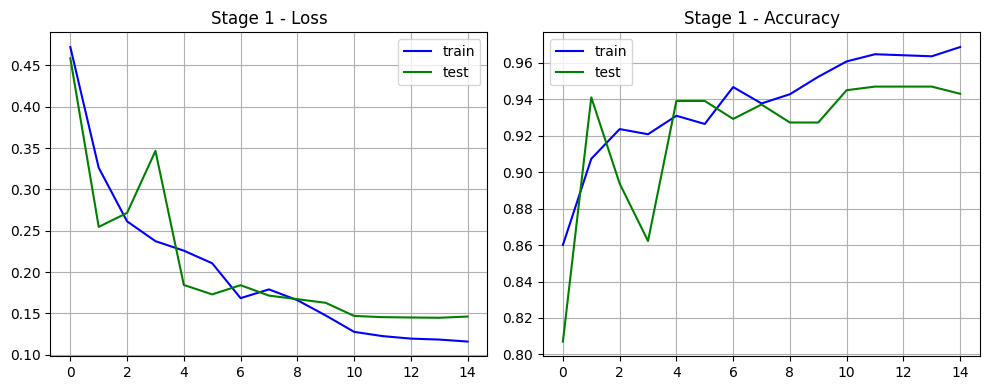

In [13]:
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    for phase, color in [('train','blue'), ('val','red'), ('test','green')]:
        if f'{phase}_loss' in history:
            axes[0].plot(history[f'{phase}_loss'], label=f'{phase}', color=color)
        if f'{phase}_acc' in history:
            axes[1].plot(history[f'{phase}_acc'], label=f'{phase}', color=color)
    axes[0].set_title(f'{title} - Loss'); axes[1].set_title(f'{title} - Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print('Saved plot to', save_path)
    plt.show()

plot_history(history_stage1, 'Stage 1', save_path=Path(config['model_dir'])/'stage1_metrics.png')
if history_stage2:
    plot_history(history_stage2, 'Stage 2', save_path=Path(config['model_dir'])/'stage2_metrics.png')


In [ ]:
def count_params_by_kind(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    quantum = 0
    for name, param in model.named_parameters():
        if 'torchlayer' in name.lower() or 'qlayer' in name.lower():
            quantum += param.numel()
    classical = total - quantum
    return total, trainable, classical, quantum

def print_model_summary(model):
    total, trainable, classical, quantum = count_params_by_kind(model)
    print(model)
    print(f'Total params: {total:,}')
    print(f'Trainable params: {trainable:,}')
    print(f'Classical params: {classical:,}')
    print(f'Quantum params: {quantum:,}')


In [14]:
metrics = {}
if 'val' in dataloaders:
    metrics['val'] = evaluate_model(best_model, dataloaders['val'], class_names, device, config['model_dir'], split_name='val')
if 'test' in dataloaders:
    metrics['test'] = evaluate_model(best_model, dataloaders['test'], class_names, device, config['model_dir'], split_name='test')
for split, vals in metrics.items():
    acc = vals.get('accuracy', 0)
    f1 = vals.get('f1_weighted', 0)
    print(f'{split.upper()} accuracy: {acc:.4f}, F1: {f1:.4f}')
print(metrics)


Evaluating (val):   0%|          | 0/61 [00:00<?, ?it/s]

VAL metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/val_metrics.json
VAL Accuracy: 0.9397 | F1: 0.9397
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/confusion_matrix_val.png


Evaluating (test):   0%|          | 0/64 [00:00<?, ?it/s]

TEST metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/test_metrics.json
TEST Accuracy: 0.9429 | F1: 0.9429
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_11-30_22-29-41/confusion_matrix_test.png
{'val': {'accuracy': 0.9397089397089398, 'precision_weighted': 0.9397695727742433, 'recall_weighted': 0.9397089397089398, 'f1_weighted': 0.9397026837460566}, 'test': {'accuracy': 0.9429133858267716, 'precision_weighted': 0.9429751809881098, 'recall_weighted': 0.9429133858267716, 'f1_weighted': 0.9429113948576854}}


Quantum head circuit (AngleEmbedding + BasicEntanglerLayers):
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  State
1: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤  State

M0 = 
[0. 0.]
M1 = 
[[0. 0.]
 [0. 0.]
 [0. 0.]]
Purity of zero-input state: 1.0000


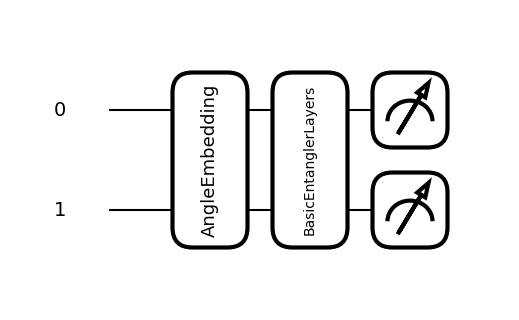

In [15]:
if USE_QUANTUM:
    try:
        analyze_trained_quantum_head(best_model, device=device, sample_input=None, print_density=True, save_dir=config.get("model_dir"))
    except Exception as exc:
        print('Quantum recap failed:', exc)
else:
    print('Quantum recap skipped (USE_QUANTUM=False)')
